In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from scipy import stats
import warnings
import gpboost as gpb
import seaborn as sns
warnings.filterwarnings('ignore')
#plt.style.use('ggplot')
# Set random seed for reproducibility
np.random.seed(42)

In [9]:
# 1. SYNTHETIC DATA GENERATION
def generate_heteroscedastic_data(n=1000, noise_type='gaussian'):
    """
    Generate 1D heteroscedastic regression data
    """
    test_size = 10000
    n = n + test_size
    x = np.random.uniform(0, 2, n).reshape(-1, 1)
    non_uniform = True
    if non_uniform:
        # resammple X and f so that X is not uniformly distributed --> sample without replacement with weights proportional X
        weights = x[:, 0]**2  # Use the first column as weights
        indices = np.random.choice(np.arange(x.shape[0]), size=x.shape[0], replace=True, p=weights/weights.sum())
        x = x[indices]
        
    # True mean function
    true_mean = 5 +  np.sin(5 * x).reshape(-1)
    
    # Heteroscedastic noise (variance increases with |x|)
    noise_std = 1 + 0.3 * (np.abs(x[:,0])*2)
    
    if noise_type == 'gaussian':
        noise = noise_std * np.random.normal(0, 1, n)
    elif noise_type == 't':
        # t-distribution noise (heavier tails)
        noise = np.random.standard_t(df=3, size=n)# * np.log(noise_std)
    
    y = true_mean + noise
    
    return x, y, noise_std

# 2. QUANTILE REGRESSION WITH GPBOOST
class QuantileGP:
    """Quantile regression with GPBoost using Asymmetric Laplace Distribution"""
    
    def __init__(self, quantile=0.5):
        self.quantile = quantile
        self.gpq = None

    def fit(self, X, y):
        """Fit GPBoost quantile regression model"""
        self.vecchia = len(y) > 1000
        self.approx = "asymmetric_laplace" #_constant_curvature"
        
        self.gpq = gpb.GPModel(
            gp_coords=X,
            cov_function="matern_ard",
            cov_fct_shape=1.5,
            gp_approx="vecchia" if self.vecchia else "none",
            num_neighbors=30,
            matrix_inversion_method="cholesky",
            likelihood=self.approx,
            likelihood_additional_param=self.quantile,
            cover_tree_radius=10,
            num_parallel_threads=1,
            likelihood_learning_rate=1,
        )
            
        self.gpq.set_optim_params({
            "cg_preconditioner_type": "vadu",
            "cg_max_num_it": 1500,
            "cg_max_num_it_tridiag": 1500,
        })
        
        params = {
            "estimate_aux_pars": True, 
            "init_aux_pars": np.array([np.std(y)]),
            "trace": False,
        }
        self.gpq.fit(X=np.ones(len(X)), y=y, params=params)
        
        return self
    
    def predict(self, X, return_std=False):
        """Make predictions with optional epistemic uncertainty"""
        pred = self.gpq.predict(
            X_pred=np.ones(len(X)),
            gp_coords_pred=X,
            predict_response=False,  # get the latent data
            predict_var=True,
        )
        
        y_pred = pred["mu"]
        
        if return_std:
            # Convert variance to standard deviation
            y_std = np.sqrt(pred["var"])
            return y_pred, y_std
        else:
            return y_pred


# 3. COMBINED CQR IMPLEMENTATION  
def combined_cqr(X_train, y_train, X_cal, y_cal, X_test, alpha=0.1):
    """
    Fit models once, then compute both standard and uncertainty-aware CQR
    """
    # Fit quantile regressors for lower and upper quantiles
    lower_quantile = alpha / 2
    upper_quantile = 1 - alpha / 2
    
    print(f"Fitting quantile regressors: {lower_quantile:.3f} and {upper_quantile:.3f}")
    
    # Fit models once
    qr_low = QuantileGP(quantile=lower_quantile)
    qr_low.fit(X_train, y_train)
    
    qr_high = QuantileGP(quantile=upper_quantile)
    qr_high.fit(X_train, y_train)
    
    # Get predictions with uncertainty on calibration set
    q_low_cal, std_low_cal = qr_low.predict(X_cal, return_std=True)
    q_high_cal, std_high_cal = qr_high.predict(X_cal, return_std=True)
    
    # Get predictions with uncertainty on test set
    q_low_test, std_low_test = qr_low.predict(X_test, return_std=True)
    q_high_test, std_high_test = qr_high.predict(X_test, return_std=True)
    
  
    # STANDARD CQR
    # Compute non-conformity scores (ignoring uncertainty)
    conformity_scores = np.maximum(q_low_cal - y_cal, y_cal - q_high_cal)
    
    # Compute global adjustment
    n_cal = len(y_cal)
    adjustment_level = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
    C = np.quantile(conformity_scores, adjustment_level)
    
    print(f"Standard CQR adjustment: C = {C:.4f}")
    
    # Apply to test set
    pi_lower_std = q_low_test - C
    pi_upper_std = q_high_test + C
    
  
    # UNCERTAINTY-AWARE CQR

    # Average epistemic uncertainty
    epistemic_uncertainty_cal = (std_low_cal + std_high_cal) / 2
    epistemic_uncertainty_test = (std_low_test + std_high_test) / 2
    
    # Find optimal scaling factor t via nested conformal prediction
    def coverage_at_t(t):
        pi_lower_cal = q_low_cal - t * std_low_cal
        pi_upper_cal = q_high_cal + t * std_high_cal
        coverage = np.mean((y_cal >= pi_lower_cal) & (y_cal <= pi_upper_cal))
        return coverage
    
    # Grid search for optimal t
    t_candidates = np.linspace(-5, 5.0, 1000)
    coverages = [coverage_at_t(t) for t in t_candidates]
    
    # Find t closest to target coverage
    target_coverage = 1 - alpha
    best_idx = np.argmin(np.abs(np.array(coverages) - target_coverage))
    t_optimal = t_candidates[best_idx]
    actual_coverage = coverages[best_idx]
    
    print(f"Uncertainty-aware optimal t = {t_optimal:.4f}, achieved coverage = {actual_coverage:.4f}")
    
    # Apply to test set
    pi_lower_aware = q_low_test - t_optimal * std_low_test
    pi_upper_aware = q_high_test + t_optimal * std_high_test
    
    return {
        'std': (pi_lower_std, pi_upper_std),
        'aware': (pi_lower_aware, pi_upper_aware),
        'models': (q_low_test, q_high_test),
        'epistemic_uncertainty': epistemic_uncertainty_test
    }

# 5. COVERAGE ANALYSIS
def compute_coverage_metrics(y_true, pi_lower, pi_upper, X=None, n_bins=10, target_coverage = 0.9):
    """
    Compute marginal and conditional coverage metrics
    """
    # Ensure all arrays are 1D and same length
    y_true = np.asarray(y_true).flatten()
    pi_lower = np.asarray(pi_lower).flatten()
    pi_upper = np.asarray(pi_upper).flatten()
    
    # Check that all arrays have the same length
    if not (len(y_true) == len(pi_lower) == len(pi_upper)):
        print(f"Array length mismatch: y_true={len(y_true)}, pi_lower={len(pi_lower)}, pi_upper={len(pi_upper)}")
        # Truncate to shortest length
        min_len = min(len(y_true), len(pi_lower), len(pi_upper))
        y_true = y_true[:min_len]
        pi_lower = pi_lower[:min_len]
        pi_upper = pi_upper[:min_len]
        print(f"Truncated all arrays to length {min_len}")
    
    # Marginal coverage
    marginal_coverage = np.mean((y_true >= pi_lower) & (y_true <= pi_upper))
    
    # Average interval width
    avg_width = np.mean(pi_upper - pi_lower)
    
    results = {
        'marginal_coverage': marginal_coverage,
        'avg_width': avg_width
    }
    
    # Conditional coverage by spatial bins (if X provided)
    if X is not None:
        X_flat = np.asarray(X).flatten()
        
        # Ensure X has same length as y and predictions
        if len(X_flat) != len(y_true):
            print(f"X length ({len(X_flat)}) doesn't match y_true length ({len(y_true)})")
            min_len = min(len(X_flat), len(y_true))
            X_flat = X_flat[:min_len]
            y_true = y_true[:min_len]
            pi_lower = pi_lower[:min_len]
            pi_upper = pi_upper[:min_len]
            print(f"Truncated all arrays to length {min_len}")
        
        bin_edges = np.quantile(X_flat, np.linspace(0, 1, n_bins + 1))
        bin_edges = np.linspace(X.flatten().min(), X.flatten().max(), n_bins + 1)

        conditional_coverages = []
        bin_centers = []
        
        for i in range(n_bins):
            mask = (X_flat >= bin_edges[i]) & (X_flat < bin_edges[i + 1])
            if i == n_bins - 1:  # Include right edge in last bin
                mask = (X_flat >= bin_edges[i]) & (X_flat <= bin_edges[i + 1])
            
            if mask.sum() > 0:
                # Now all arrays have the same length, so masking will work
                y_masked = y_true[mask]
                pi_lower_masked = pi_lower[mask]
                pi_upper_masked = pi_upper[mask]
                
                bin_coverage = np.mean((y_masked >= pi_lower_masked) & 
                                     (y_masked <= pi_upper_masked))
                conditional_coverages.append(bin_coverage)
                bin_centers.append((bin_edges[i] + bin_edges[i + 1]) / 2)
        
        results['conditional_coverages'] = conditional_coverages
        results['bin_centers'] = bin_centers
        results["bin_edges"] = bin_edges
        results['conditional_coverage_mse'] = np.mean(np.abs(np.array(conditional_coverages) - target_coverage))
    
    return results


# VISUALIZATION
def set_style():
    mpl.rcParams.update({
        # Export / vector text
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # Typography (JMLR-ish)
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 12,

        # Clean axes
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,

        # Lines
        "lines.linewidth": 1.2,
    })


def plot_conditional_coverage(results_std, results_aware, target_coverage=0.9):
    """
    Plot conditional coverage comparison
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Bar plot comparison
    bin_centers = results_std['bin_centers']
    bin_edges = results_std["bin_edges"]
    width = 0.35
    x_pos = np.arange(len(bin_centers))
    
    ax1.bar(x_pos - width/2, results_std['conditional_coverages'], width, 
           label='Standard CQR', alpha=0.7, color='red')
    ax1.bar(x_pos + width/2, results_aware['conditional_coverages'], width,
           label='Uncertainty-aware CQR', alpha=0.7, color='green')
    
    ax1.axhline(y=target_coverage, color='black', linestyle='--', label='Target coverage')
    ax1.set_xlabel('Spatial bin')
    ax1.set_ylabel('Coverage')
    ax1.set_title('Conditional Coverage')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f"[{bin_edges[i]:.2f}, {bin_edges[i + 1]:.2f}]" for i in range(len(bin_edges)-1)], rotation=45)
    ax1.legend(labelcolor="black")
    ax1.grid(True, alpha=0.3)
    
    # Coverage variance comparison
    methods = ['Standard CQR', 'Uncertainty-aware CQR']
    coverage_stds = [results_std['conditional_coverage_mse'], results_aware['conditional_coverage_mse']]
    
    ax2.bar(methods, coverage_stds, alpha=0.7, color=['red', 'green'])
    ax2.set_ylabel('Standard deviation of conditional coverage')
    ax2.set_title('Coverage Uniformity Comparison')
    ax2.grid(True, alpha=0.3)
    
    # Add text annotations
    for i, v in enumerate(coverage_stds):
        ax2.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', color = "black")
    
    plt.tight_layout()
    plt.show()

def plot_results(X_test, y_test, pi_lower_std, pi_upper_std, pi_lower_aware, pi_upper_aware, results_models,
                 epistemic_uncertainty=None):
    """
    Plot comparison of standard vs uncertainty-aware CQR
    """
    # Ensure all arrays are same length for plotting
    min_len = min(len(X_test), len(y_test), len(pi_lower_std), len(pi_upper_std), 
                  len(pi_lower_aware), len(pi_upper_aware))
    
    X_test = X_test[:min_len]
    y_test = y_test[:min_len]
    pi_lower_std = pi_lower_std[:min_len]
    pi_upper_std = pi_upper_std[:min_len]
    pi_lower_aware = pi_lower_aware[:min_len]
    pi_upper_aware = pi_upper_aware[:min_len]
    gpq_lower = results_models[0][:min_len]
    gpq_upper = results_models[1][:min_len]
    
    if epistemic_uncertainty is not None:
        epistemic_uncertainty = epistemic_uncertainty[:min_len]
    
    # Sort for better visualization
    sort_idx = np.argsort(X_test.flatten())
    X_sorted = X_test[sort_idx]
    y_sorted = y_test[sort_idx]
    pi_lower_std_sorted = pi_lower_std[sort_idx]
    pi_upper_std_sorted = pi_upper_std[sort_idx]
    pi_lower_aware_sorted = pi_lower_aware[sort_idx]
    pi_upper_aware_sorted = pi_upper_aware[sort_idx]
    gpq_lower_sorted = gpq_lower[sort_idx]
    gpq_upper_sorted = gpq_upper[sort_idx]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Standard CQR
    axes[0].scatter(X_sorted, y_sorted, alpha=0.6, s=20, color='blue', label='Test data')
    axes[0].fill_between(X_sorted.flatten(), pi_lower_std_sorted, pi_upper_std_sorted, 
                        alpha=0.3, color='red', label='Standard CQR')
    axes[0].fill_between(X_sorted.flatten(), gpq_lower_sorted, gpq_upper_sorted, 
                        alpha=0.3, color='yellow', label='GPBoost')
    
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y') 
    axes[0].set_title('Standard CQR')
    axes[0].legend(labelcolor="black")
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Uncertainty-aware CQR
    axes[1].scatter(X_sorted, y_sorted, alpha=0.6, s=20, color='blue', label='Test data')
    axes[1].fill_between(X_sorted.flatten(), pi_lower_aware_sorted, pi_upper_aware_sorted,
                        alpha=0.3, color='green', label='Uncertainty-aware CQR')
    axes[1].fill_between(X_sorted.flatten(), gpq_lower_sorted, gpq_upper_sorted, 
                        alpha=0.3, color='yellow', label='GPBoost')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    axes[1].set_title('Uncertainty-aware CQR')
    axes[1].legend(labelcolor="black")
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Comparison
    axes[2].scatter(X_sorted, y_sorted, alpha=0.6, s=20, color='blue', label='Test data')
    axes[2].fill_between(X_sorted.flatten(), pi_lower_std_sorted, pi_upper_std_sorted,
                        alpha=0.3, color='red', label='Standard CQR')
    axes[2].fill_between(X_sorted.flatten(), pi_lower_aware_sorted, pi_upper_aware_sorted,
                        alpha=0.3, color='green', label='Uncertainty-aware CQR')
    
    # Add epistemic uncertainty if provided
    if epistemic_uncertainty is not None:
        epistemic_sorted = epistemic_uncertainty[sort_idx]
        ax2 = axes[2].twinx()
        ax2.plot(X_sorted, epistemic_sorted, 'black', linewidth=2, label='Epistemic uncertainty')
        ax2.set_ylabel('Epistemic uncertainty', color='black')
        ax2.tick_params(axis='y', labelcolor='black')
    
    axes[2].set_xlabel('X')
    axes[2].set_ylabel('Y')
    axes[2].set_title('Comparison')
    axes[2].legend(loc='upper left', labelcolor="black")
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()



# MAIN EXPERIMENT
def run_experiment(n_samples=1000, noise_type='gaussian', alpha=0.1, test_size=0.3, cal_size=0.2):
    """
    Run complete conformal prediction experiment
    """
    print("="*60)
    print(f"CONFORMAL PREDICTION EXPERIMENT")
    print(f"Noise type: {noise_type}")
    print(f"Sample size: {n_samples}")
    print(f"Target coverage: {1-alpha:.1%}")
    print("="*60)
    
    # Generate data
    sns.set_style("whitegrid")
    set_style()
    X_full, y_full, true_noise_std = generate_heteroscedastic_data(n_samples, noise_type)
    X_test = X_full[n_samples:]
    y_test = y_full[n_samples:]
    X = X_full[:n_samples]
    y = y_full[:n_samples]
    # Split data: train / calibration / test
    X_train, X_cal, y_train, y_cal = train_test_split(X, y, test_size=cal_size, random_state=42)
    
    
    print(f"Data splits - Train: {len(X_train)}, Cal: {len(X_cal)}, Test: {len(X_test)}")
    
    # Combined CQR (fit once, get both adjustments)
    print("\n" + "="*40)
    print("COMBINED CQR FITTING")
    print("="*40)
    
    results = combined_cqr(X_train, y_train, X_cal, y_cal, X_test, alpha)
    results_models = results["models"]

    # Extract results
    pi_lower_std, pi_upper_std = results['std']
    pi_lower_aware, pi_upper_aware = results['aware']
    epistemic_uncertainty = results['epistemic_uncertainty']
    
    # Compute coverage metrics
    print("\n" + "="*40)
    print("COVERAGE ANALYSIS")
    print("="*40)
    
    results_std = compute_coverage_metrics(y_test, pi_lower_std, pi_upper_std, X_test, 10, 1-alpha)
    results_aware = compute_coverage_metrics(y_test, pi_lower_aware, pi_upper_aware, X_test,10, 1 -alpha)
    
    # Print results
    print(f"\nSTANDARD CQR:")
    print(f"  Marginal coverage: {results_std['marginal_coverage']:.4f}")
    print(f"  Average width: {results_std['avg_width']:.4f}")
    print(f"  Conditional coverage std: {results_std['conditional_coverage_mse']:.4f}")
    
    print(f"\nUNCERTAINTY-AWARE CQR:")
    print(f"  Marginal coverage: {results_aware['marginal_coverage']:.4f}")
    print(f"  Average width: {results_aware['avg_width']:.4f}")
    print(f"  Conditional coverage std: {results_aware['conditional_coverage_mse']:.4f}")
    
    print(f"\nIMPROVEMENT:")
    coverage_improvement = results_aware['conditional_coverage_mse'] / results_std['conditional_coverage_mse']
    print(f"  Conditional coverage uniformity: {coverage_improvement:.4f}x better (lower is better)")
    
    # Visualizations
    plot_results(X_test, y_test, pi_lower_std, pi_upper_std, pi_lower_aware, pi_upper_aware, results_models, epistemic_uncertainty)
    plot_conditional_coverage(results_std, results_aware, 1-alpha)
    
    return {
        'results_std': results_std,
        'results_aware': results_aware,
        'X_test': X_test,
        'y_test': y_test,
        'pi_std': (pi_lower_std, pi_upper_std),
        'pi_aware': (pi_lower_aware, pi_upper_aware),
        'epistemic_uncertainty': epistemic_uncertainty
    }

EXPERIMENT 1: GAUSSIAN NOISE (ALD vs Gaussian)
CONFORMAL PREDICTION EXPERIMENT
Noise type: gaussian
Sample size: 1000
Target coverage: 80.0%
Data splits - Train: 500, Cal: 500, Test: 10000

COMBINED CQR FITTING
Fitting quantile regressors: 0.100 and 0.900
Standard CQR adjustment: C = 0.1820
Uncertainty-aware optimal t = 1.0060, achieved coverage = 0.8000

COVERAGE ANALYSIS

STANDARD CQR:
  Marginal coverage: 0.8170
  Average width: 5.0736
  Conditional coverage std: 0.0662

UNCERTAINTY-AWARE CQR:
  Marginal coverage: 0.8123
  Average width: 5.0109
  Conditional coverage std: 0.0303

IMPROVEMENT:
  Conditional coverage uniformity: 0.4581x better (lower is better)


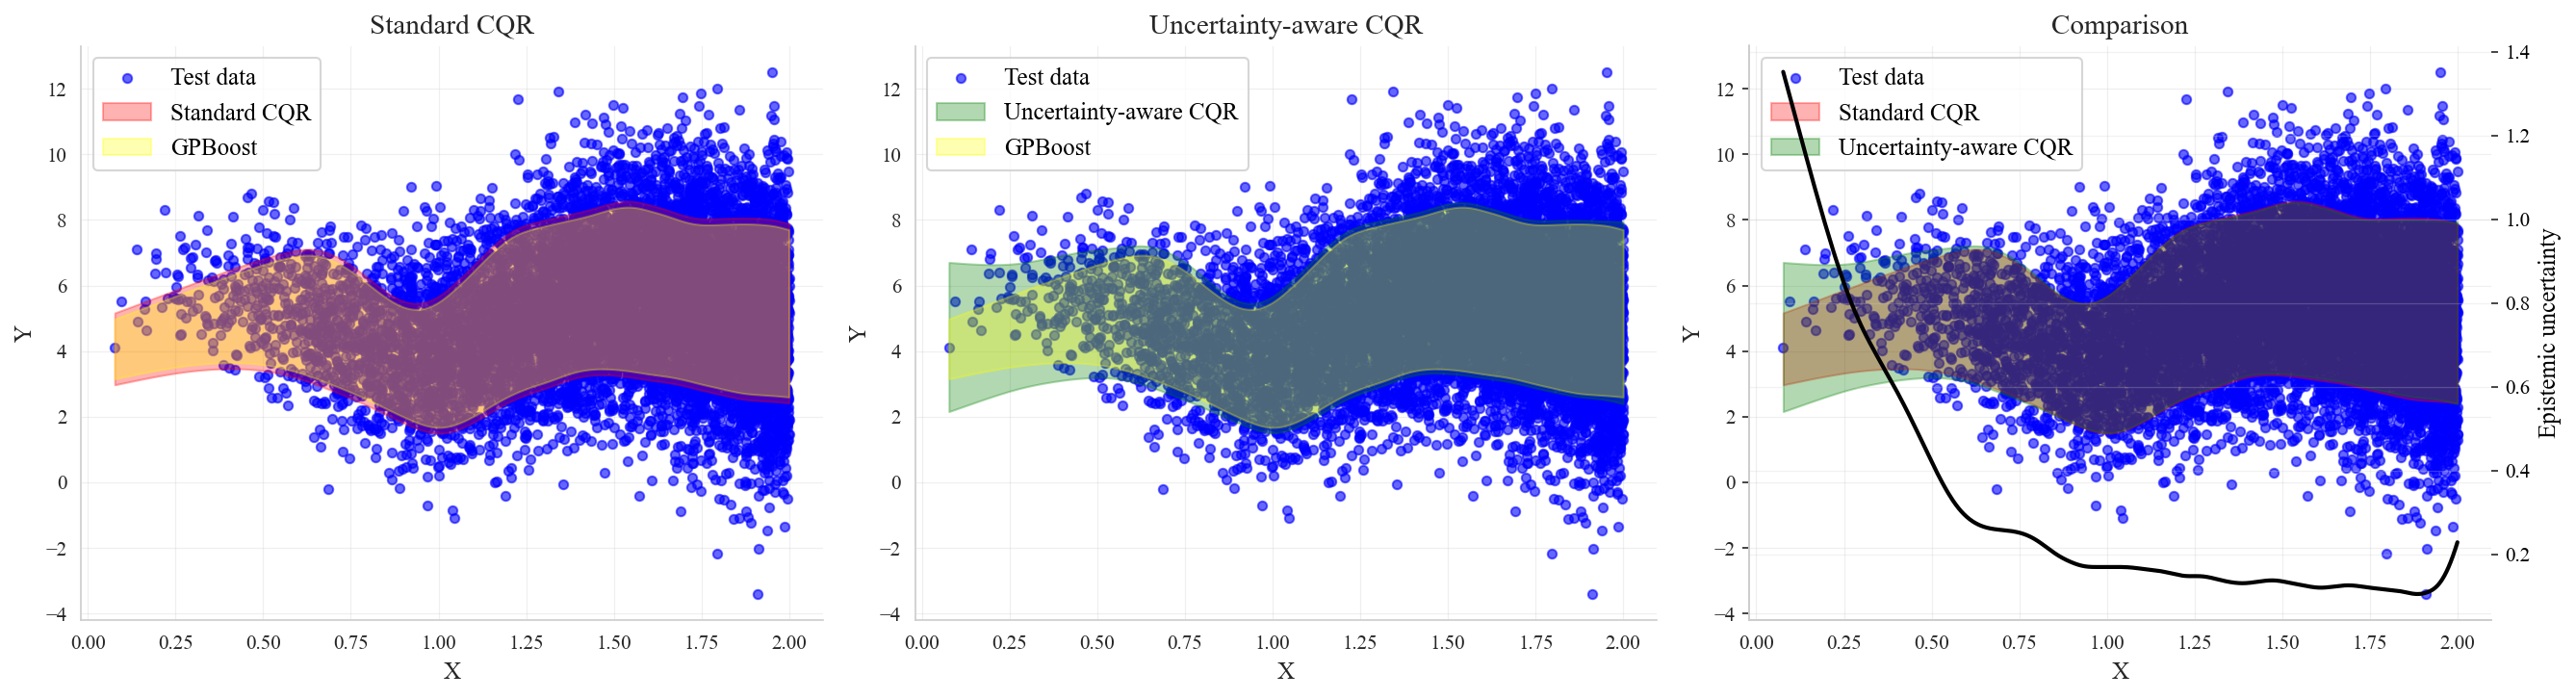

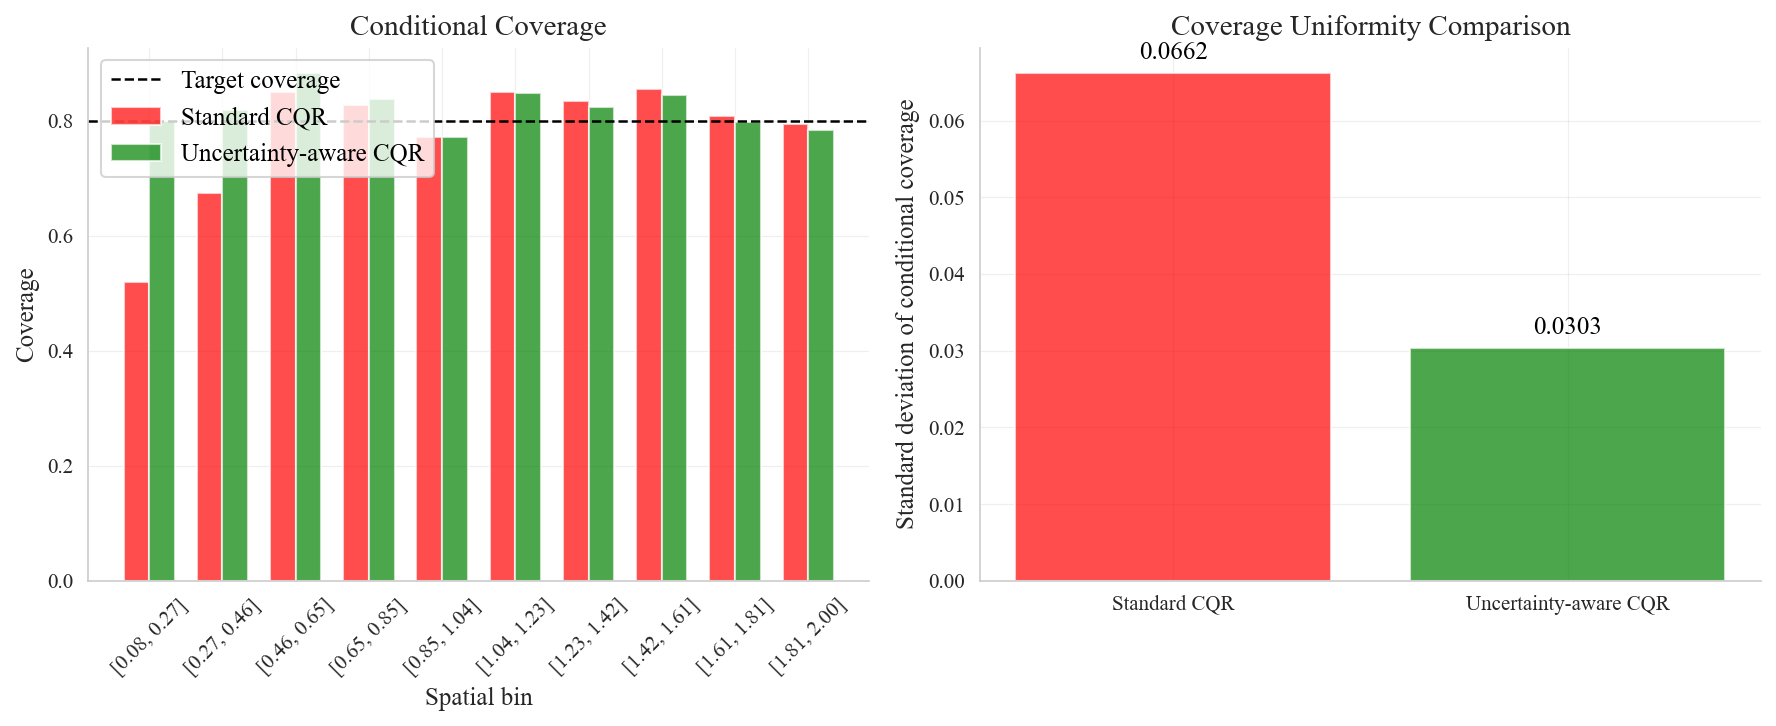

In [10]:
#  RUN EXPERIMENTS
if __name__ == "__main__":
    # Experiment 1: Gaussian noise (model misspecification)
    print("EXPERIMENT 1: GAUSSIAN NOISE (ALD vs Gaussian)")
    results_gaussian = run_experiment(n_samples=1000, cal_size= 0.5, noise_type='gaussian', alpha=0.2)
